## Question 2 
The dataset electric_production.csv recorded the monthly electric production over time.

### (a) 
Draw the time series plot. Attach the plots in the pdf.

In [204]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import statsmodels.api as sm
import datetime
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

os.chdir('/Users/tomas/Documents/2.3_USF MSDS/MSDS604/hw1')

electric = pd.read_csv('electric_production.csv')
electric["DATE"] = pd.to_datetime(electric["DATE"], format="%m-%d-%Y", errors="coerce")
electric["Value"] = pd.to_numeric(electric["Value"], errors="coerce")
electric.info()
electric.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    397 non-null    datetime64[ns]
 1   Value   397 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 6.3 KB


,DATE,Value
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151


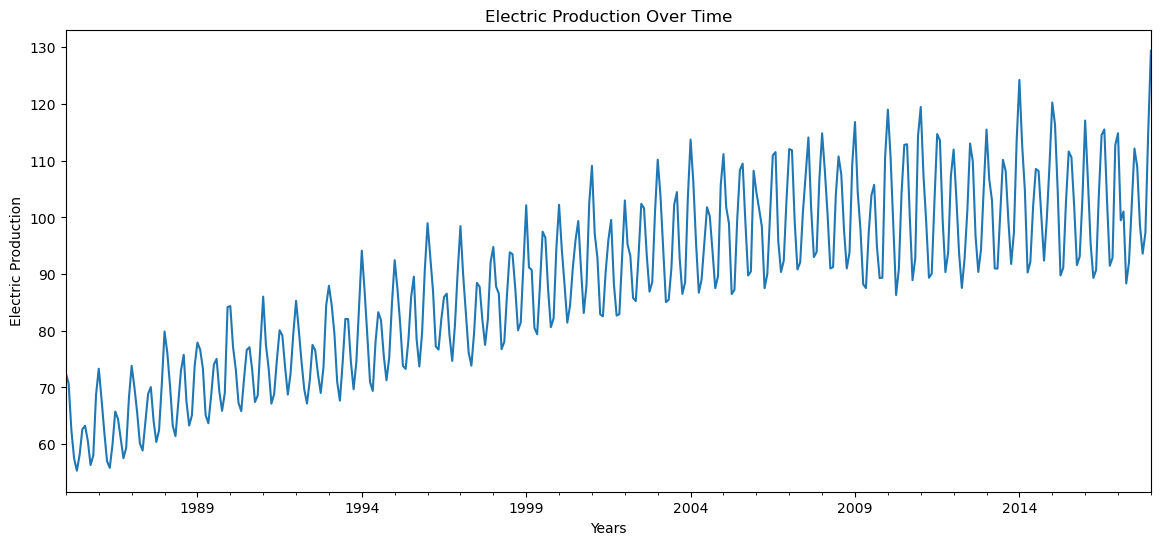

In [205]:
electric.plot(x='DATE', y='Value', kind='line', legend=False, figsize=(14, 6))
plt.title('Electric Production Over Time')
plt.xlabel('Years')
plt.ylabel('Electric Production')
plt.show()

### (b) 
Based on the data and time series plot, choose the "model" and "freq" for classical
decomposition and create the decomposition plot.

#### i. 
Report the "model" and "freq" of your choice.

Based on the plot below, this is an multiplicative model with a frequency of 12 (this is monthly data that appears to be seasonal over the course of the year). We know this is correct because the seasonal plot shows the seasonal fluctuations to be constant magnitude over the timeseries. I also compared the RMSE values between the additive and multiplicate model and the multiplicative model yielded lower RMSE value.

#### ii. 
Attach the decomposition plot.

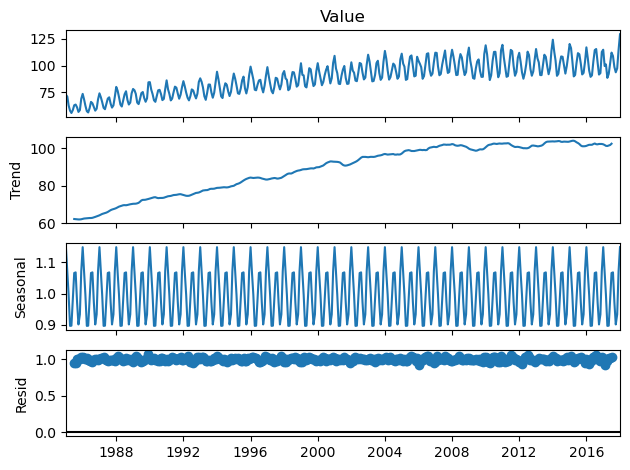

In [206]:
electric_for_decomp = electric.copy()

electric_for_decomp = electric_for_decomp.dropna(subset=["DATE", "Value"]).sort_values("DATE").set_index("DATE")
res = sm.tsa.seasonal_decompose(electric_for_decomp["Value"], period=12, model="multiplicative")
res.plot()
plt.show()

#### iii. 
Research: Find how to call the estimated trend $\hat{m}_t$, seasonality $\hat{s}_t$ and residuals $\epsilon_t$ from the decomposition result. Calculate the RMSE from residuals. This RMSE is the RMSE if you use the classical decomposition method to estimate this time series data. Report the RMSE as the answer to this question.

Estimated trend, $\hat{m}_t$, can be obtained by calling the .trend attribute. 

In [207]:
m_t = res.trend
m_t.head(20)


DATE
1985-01-01          NaN
1985-02-01          NaN
1985-03-01          NaN
1985-04-01          NaN
1985-05-01          NaN
1985-06-01          NaN
1985-07-01    62.199021
1985-08-01    62.120496
1985-09-01    61.999112
1985-10-01    61.971337
1985-11-01    61.973842
1985-12-01    62.070037
1986-01-01    62.276512
1986-02-01    62.458946
1986-03-01    62.527654
1986-04-01    62.595683
1986-05-01    62.702267
1986-06-01    62.734021
1986-07-01    62.731121
1986-08-01    62.838812
Name: trend, dtype: float64

Seasonality, $\hat{s}_t$, can be obtained by calling the .seasonal attribute.

In [208]:
s_t = res.seasonal
s_t.head(20)

DATE
1985-01-01    1.149172
1985-02-01    1.065875
1985-03-01    0.995985
1985-04-01    0.896027
1985-05-01    0.896724
1985-06-01    0.984900
1985-07-01    1.066145
1985-08-01    1.068081
1985-09-01    0.971682
1985-10-01    0.900691
1985-11-01    0.933050
1985-12-01    1.071668
1986-01-01    1.149172
1986-02-01    1.065875
1986-03-01    0.995985
1986-04-01    0.896027
1986-05-01    0.896724
1986-06-01    0.984900
1986-07-01    1.066145
1986-08-01    1.068081
Name: seasonal, dtype: float64

Residuals, $\epsilon_t$ can be obtained by calling the .resid attribute.

In [209]:
preds_mult = m_t * s_t
e_t = electric_for_decomp["Value"] - preds_mult
e_t.head(20)

DATE
1985-01-01         NaN
1985-02-01         NaN
1985-03-01         NaN
1985-04-01         NaN
1985-05-01         NaN
1985-06-01         NaN
1985-07-01   -3.692996
1985-08-01   -3.101220
1985-09-01    0.341194
1985-10-01    0.498388
1985-11-01    0.175826
1985-12-01    2.196050
1986-01-01    1.739282
1986-02-01    1.413460
1986-03-01   -0.054530
1986-04-01    0.945474
1986-05-01   -0.412949
1986-06-01   -1.886237
1986-07-01   -1.114991
1986-08-01   -2.635340
dtype: float64

Root Mean Squared Error (RMSE) can be calculated as follows:

In [210]:
e_t_cleaned = e_t.dropna()

rmse = np.sqrt((e_t_cleaned**2).mean())
print(f"RMSE: {rmse:.4f}")

RMSE: 2.2434


### (c)
With the explanation of the "DIY" decomposition models in the lecture notes, combine
your knowledge from regression:

#### i. 
Choose an order for the polynomial regression that you think best describes the
trend you have observed and fit a regression model. For example, if you think a
straight line best fits the trend, you will fit a regression model y= a + b * t. Note:
you might need to define a column t= 0, 1, 2, ... in your data for the time steps.
You can also use some model selection metrics (RMSE for example) to choose the
polynomial order. In the answer, provide the estimated model for the trend such
as: $\hat{m}_t$ = a + b * t.

Rows before: 397
NaNs in trend: 12
Rows after: 385

### Polynomial Regression Results
|   Degree |    RMSE |   Intercept | Coefficients                                                                                                       |
|---------:|--------:|------------:|:-------------------------------------------------------------------------------------------------------------------|
|        1 | 3.45783 |     66.8398 | [1.1176e-01]                                                                                                       |
|        2 | 1.33105 |     59.0831 | [2.2615e-01 -2.8887e-04]                                                                                           |
|        3 | 1.12224 |     61.3132 | [1.6285e-01 1.0537e-04 -6.6370e-07]                                                                                |
|        4 | 1.12102 |     61.1083 | [1.7209e-01 3.5279e-06 -2.6727e-07 -5.0055e-10]                                                            

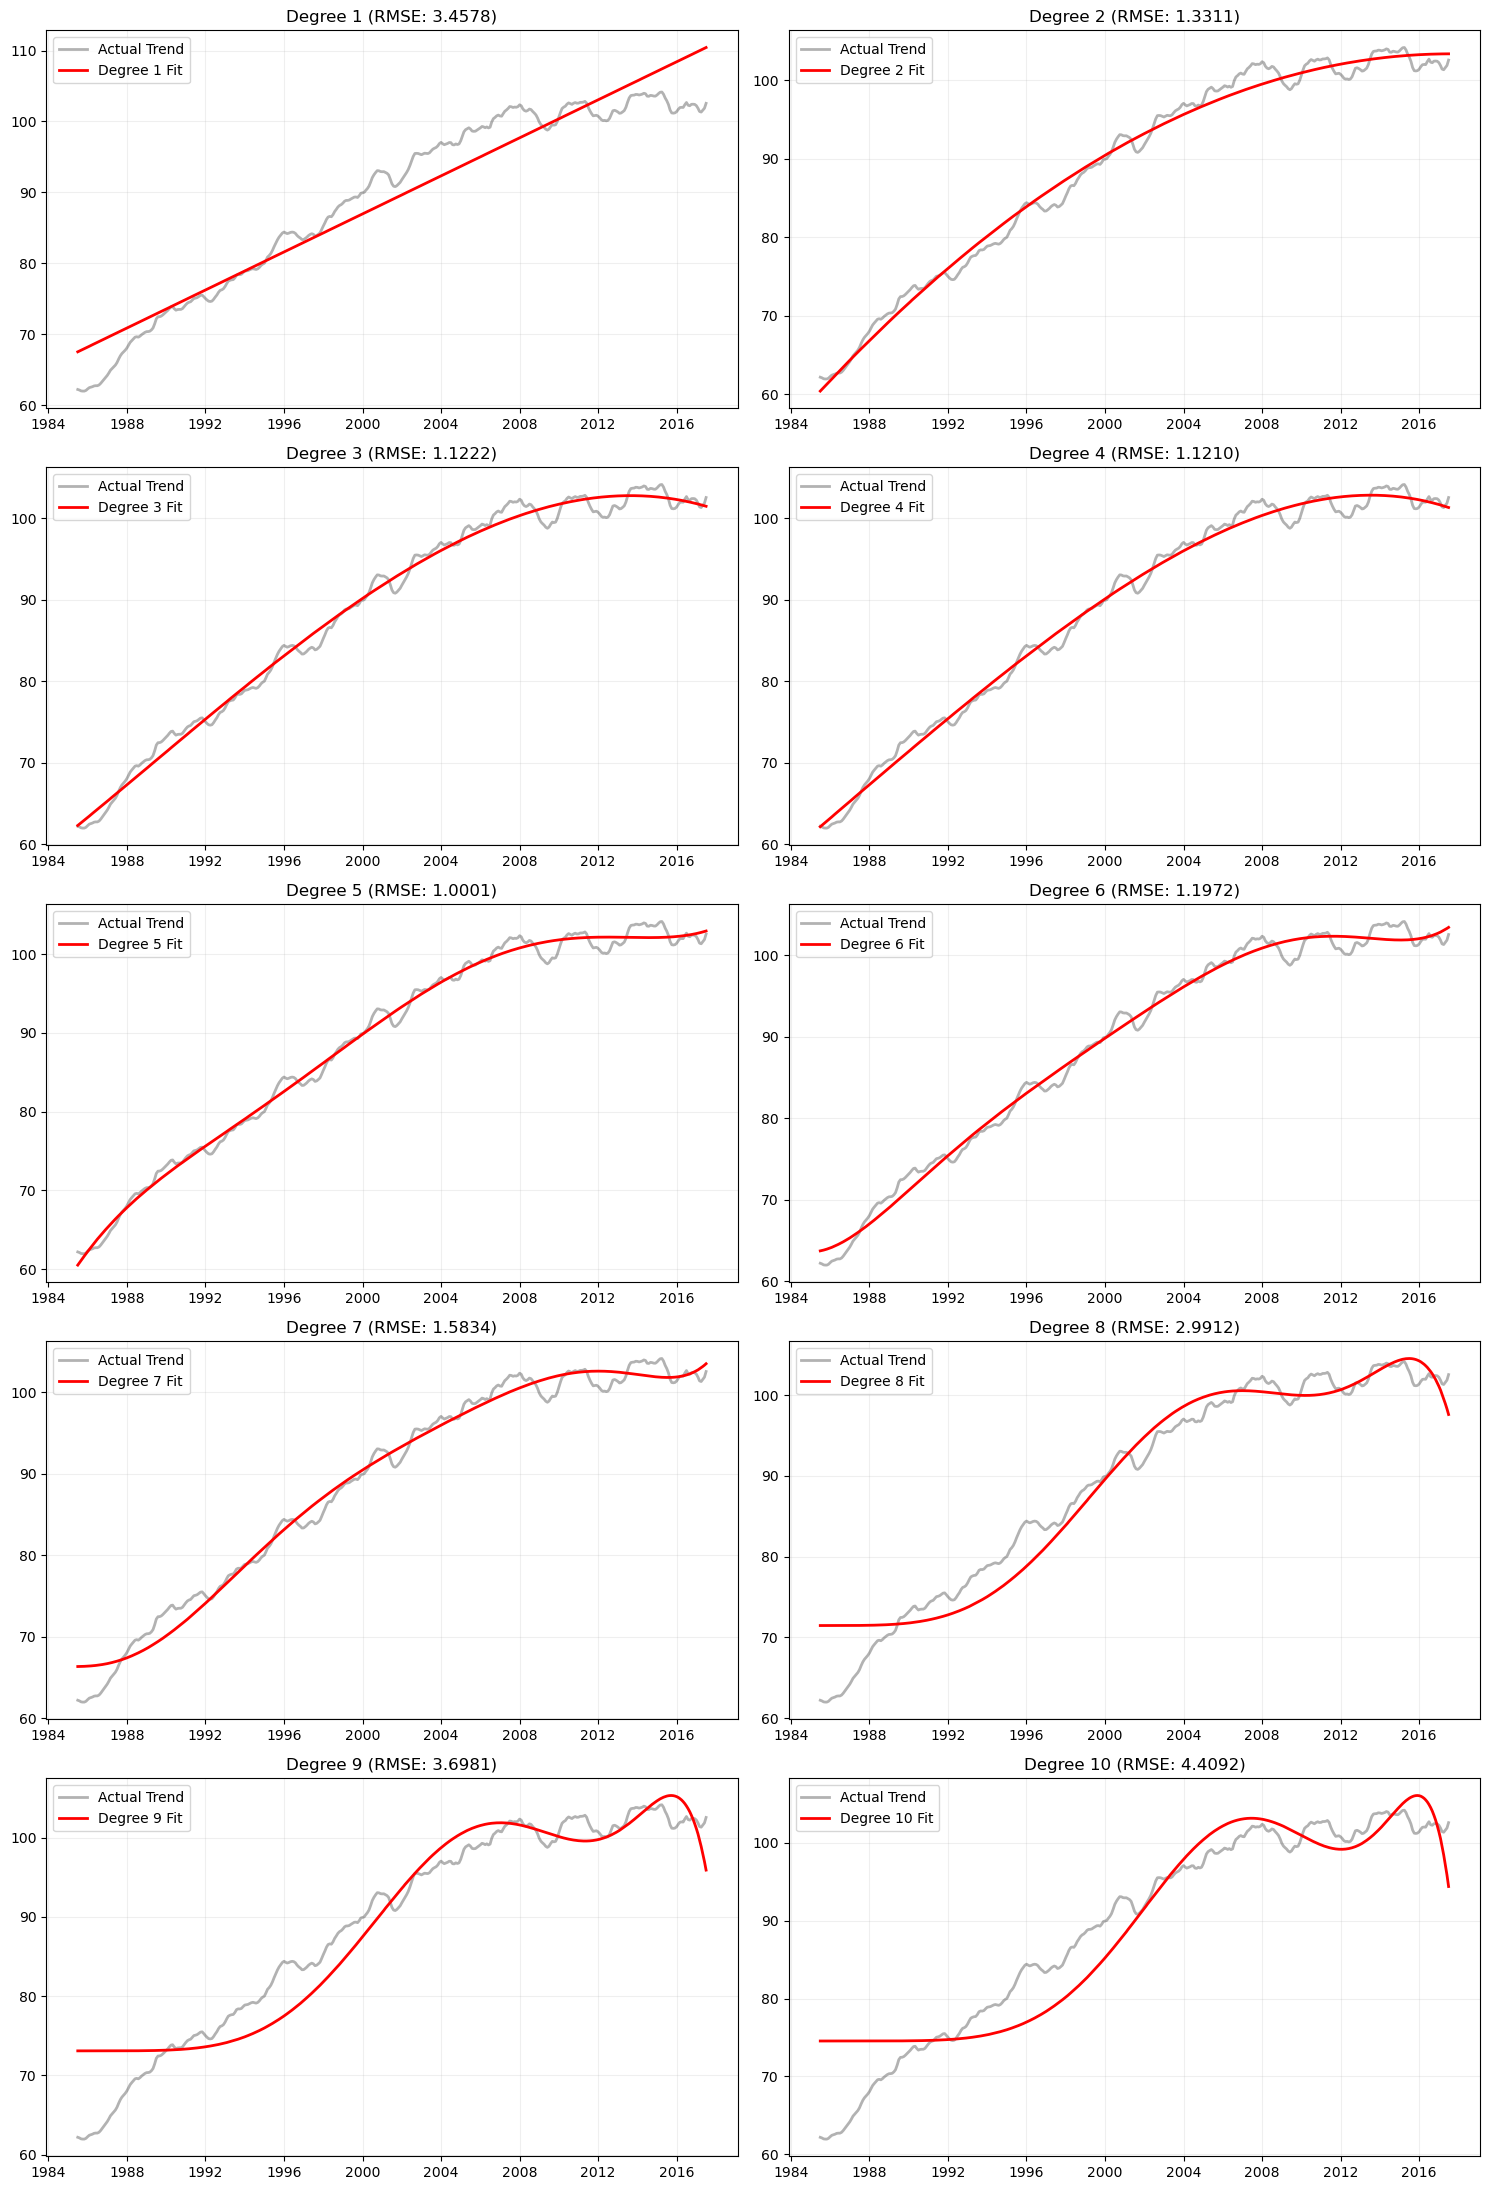

------------------------------
BEST MODEL DETAILS (Degree 5)
------------------------------
RMSE: 1.000114
Equation:
y = 58.6332 + 3.3071e-01*x^1 - 2.6574e-03*x^2 + 1.7293e-05*x^3 - 5.0047e-08*x^4 + 5.0047e-11*x^5


In [211]:
# --- 1. DATA PREPARATION ---
electric_for_poly = m_t.to_frame(name='trend_values')
electric_for_poly['Time_Index'] = np.arange(len(electric_for_poly))

print(f"Rows before: {len(electric_for_poly)}")
print(f"NaNs in trend: {electric_for_poly['trend_values'].isna().sum()}")
electric_for_poly.dropna(subset=['trend_values'], inplace=True)
print(f"Rows after: {len(electric_for_poly)}\n")

X = electric_for_poly[['Time_Index']]
y = electric_for_poly['trend_values']

# --- 2. MODEL EVALUATION LOOP ---
results = []
models_cache = {} 

for degree in range(1, 11):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Store raw data for math, but we will format it for the table below
    results.append({
        'Degree': degree, 
        'RMSE': rmse,
        'Intercept': model.intercept_,
        'Coefficients': model.coef_[1:] 
    })
    
    models_cache[degree] = y_pred

# Create results dataframe
results_df = pd.DataFrame(results)

# --- FORMATTING FOR THE TABLE ---
# Display version of the dataframe with scientific notation
display_df = results_df.copy()

# Format Intercept to 4 decimal places
display_df['Intercept'] = display_df['Intercept'].map('{:.4f}'.format)

# Format Coefficients list to a string of scientific notations
display_df['Coefficients'] = display_df['Coefficients'].apply(
    lambda x: "[" + " ".join([f"{val:.4e}" for val in x]) + "]"
)

# --- 3. OUTPUT: FULL RESULTS TABLE ---
print("### Polynomial Regression Results")
print(display_df.to_markdown(index=False))

# Use the original results_df to find the best model for the equation
best_idx = results_df['RMSE'].idxmin()
best_res = results[best_idx]
print(f"\nBest Model: Degree {int(best_res['Degree'])} with RMSE: {best_res['RMSE']:.4f}\n")


# --- 4. OUTPUT: PLOTS ---
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 22))
axes = axes.flatten()

for i, degree in enumerate(range(1, 11)):
    ax = axes[i]
    y_pred = models_cache[degree]
    
    ax.plot(electric_for_poly.index, y, label='Actual Trend', color='black', alpha=0.3, lw=2)
    ax.plot(electric_for_poly.index, y_pred, label=f'Degree {degree} Fit', color='red', lw=2)
    
    ax.set_title(f"Degree {degree} (RMSE: {results[i]['RMSE']:.4f})")
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# --- 5. OUTPUT: BEST MODEL EQUATION ---
intercept = best_res['Intercept']
coefs = best_res['Coefficients'] # Using the raw coefficients for high precision

equation_parts = [f"{intercept:.4f}"]
for i, coef in enumerate(coefs):
    power = i + 1
    sign = " + " if coef >= 0 else " - "
    equation_parts.append(f"{sign}{abs(coef):.4e}*x^{power}")

full_equation = "y = " + "".join(equation_parts)

print("-" * 30)
print(f"BEST MODEL DETAILS (Degree {int(best_res['Degree'])})")
print("-" * 30)
print(f"RMSE: {best_res['RMSE']:.6f}")
print(f"Equation:\n{full_equation}")

#### ii. 
Generate the trend estimates $\hat{m}_t$ from the above model and detrend the data. Note
that if you have chosen an additive model in part (b), here the detrend data is
${d}_t$ = ${y}_t$ - $\hat{m}_t$; if you have chosen a multiplicative model in part (b), here the
detrend data is ${d}_t$ = ${y}_t$ / $\hat{m}_t$. Fit a harmonics regression to ${d}_t$ to estimate the sea-
sonality. Again, you need to research and design how to choose the parameters
and orders involved in your model. In the answer, provide the estimated model
for the seasonality such as: 
$\hat{s}_t$ = $a_0$ + acos($f_t$) + bsin($f_t$).

Rows: 385


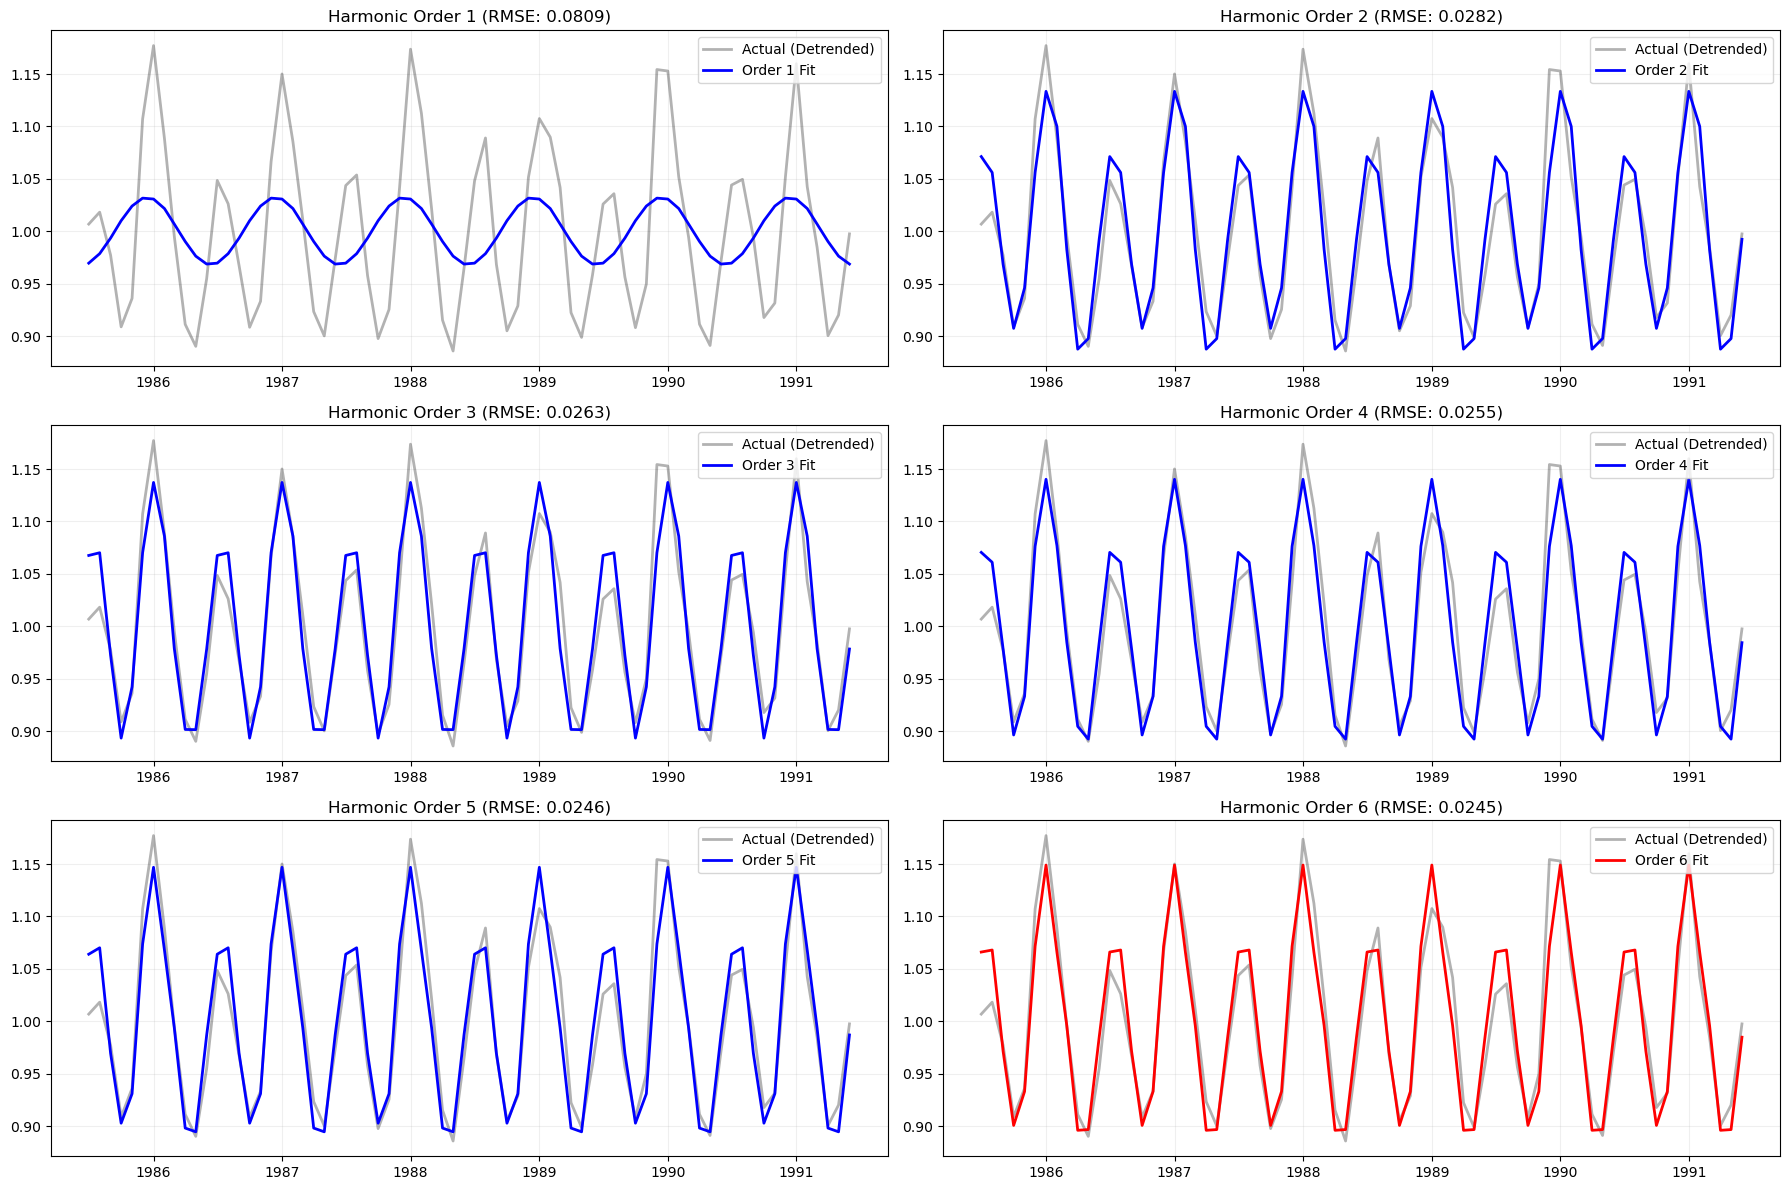

### Harmonic Regression Results
|   Order |      RMSE |   Intercept | Coefficients                                                                                                                  |
|--------:|----------:|------------:|:------------------------------------------------------------------------------------------------------------------------------|
|       1 | 0.0808927 |      1.0001 | [-9.925e-03 3.059e-02]                                                                                                        |
|       2 | 0.0282421 |      0.9998 | [-9.925e-03 3.112e-02 3.107e-02 1.025e-01]                                                                                    |
|       3 | 0.0263091 |      0.9998 | [-9.925e-03 3.110e-02 3.107e-02 1.025e-01 -1.405e-02 3.740e-03]                                                               |
|       4 | 0.0254888 |      0.9998 | [-9.925e-03 3.111e-02 3.107e-02 1.025e-01 -1.405e-02 3.756e-03 -8.732e-03 2.985e-03]                

In [212]:
# --- 1. PREPARE DETRENDED DATA (Critical Fixes Included) ---
# Use the ORIGINAL observed data (y_observed) and divide by the Trend (m_t)
y_observed = res.observed 

# Calculate Detrended Series (Multiplicative: Observed / Trend)
detrended_series = y_observed / m_t

# Create a clean dataframe for modeling
model_data = detrended_series.to_frame(name='detrended')
model_data['Time_Index'] = np.arange(len(model_data))

# Drop NaNs created by the trend moving average so sklearn doesn't crash
model_data.dropna(subset=['detrended'], inplace=True)

# Define inputs for the loop
detrended_y = model_data['detrended']
# Ensure time_index aligns perfectly with the cleaned data
time_index = model_data['Time_Index'].values.reshape(-1, 1)

print(f"Rows: {len(model_data)}")

# --- 2. MODEL EVALUATION LOOP (Orders 1-6) ---
orders = range(1, 7) 
results_seasonal = []
models_seasonal_cache = {}

for k in orders:
    features = []
    feature_names = []
    
    for i in range(1, k + 1):
        # Create Sin and Cos terms for the i-th harmonic
        features.append(np.sin(2 * np.pi * i * time_index / 12))
        features.append(np.cos(2 * np.pi * i * time_index / 12))
        feature_names.append(f"sin({2*i}πt/12)")
        feature_names.append(f"cos({2*i}πt/12)")
        
    X_seasonal = np.column_stack(features)
    
    # Fit model
    model = LinearRegression().fit(X_seasonal, detrended_y)
    s_t_pred = model.predict(X_seasonal)
    rmse = np.sqrt(mean_squared_error(detrended_y, s_t_pred))
    
    results_seasonal.append({
        'Order': k,
        'RMSE': rmse,
        'Intercept': model.intercept_,
        'Coefficients': model.coef_,
        'Feature_Names': feature_names
    })
    
    models_seasonal_cache[k] = s_t_pred

# --- 3. PLOTTING ALL 6 ORDERS ---
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
axes = axes.flatten()

# Plot a slice (e.g., first 72 months / 6 years) to make the wave pattern visible
plot_slice = 72 

for i, k in enumerate(orders):
    ax = axes[i]
    s_pred = models_seasonal_cache[k]
    
    # Plot Actual Detrended Data (Black)
    ax.plot(model_data.index[:plot_slice], detrended_y.iloc[:plot_slice], 
            label='Actual (Detrended)', color='black', alpha=0.3, lw=2)
    
    # Plot Model Fit (Blue/Red)
    # Highlight the 'Best' model (lowest RMSE) in Red, others in Blue
    is_best = (k == pd.DataFrame(results_seasonal).sort_values('RMSE').iloc[0]['Order'])
    color = 'red' if is_best else 'blue'
    
    ax.plot(model_data.index[:plot_slice], s_pred[:plot_slice], 
            label=f'Order {k} Fit', color=color, lw=2)
    
    ax.set_title(f"Harmonic Order {k} (RMSE: {results_seasonal[i]['RMSE']:.4f})")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# --- 4. RESULTS TABLE & EQUATION ---
results_df_s = pd.DataFrame(results_seasonal)
display_df_s = results_df_s.copy()
display_df_s['Intercept'] = display_df_s['Intercept'].map('{:.4f}'.format)
display_df_s['Coefficients'] = display_df_s['Coefficients'].apply(
    lambda x: "[" + " ".join([f"{val:.3e}" for val in x]) + "]"
)

print("### Harmonic Regression Results")
print(display_df_s[['Order', 'RMSE', 'Intercept', 'Coefficients']].to_markdown(index=False))

best_idx_s = results_df_s['RMSE'].idxmin()
best_res_s = results_seasonal[best_idx_s]

# Build Equation String
intercept = best_res_s['Intercept']
equation_parts = [f"{intercept:.4f}"]
for coef, name in zip(best_res_s['Coefficients'], best_res_s['Feature_Names']):
    sign = " + " if coef >= 0 else " - "
    equation_parts.append(f"{sign}{abs(coef):.4f}*{name}")

print("\n" + "-" * 50)
print(f"BEST MODEL: Order {best_res_s['Order']} (RMSE: {best_res_s['RMSE']:.6f})")
print("-" * 50)
print(f"s_t = {''.join(equation_parts)}")

----------------------------------------
FINAL CHOSEN MODEL (Order 2)
----------------------------------------
RMSE: 0.028242

Final Seasonal Equation:
s_t = 0.9998 - 0.0099*sin(2πt/12) + 0.0311*cos(2πt/12) + 0.0311*sin(4πt/12) + 0.1025*cos(4πt/12)
----------------------------------------


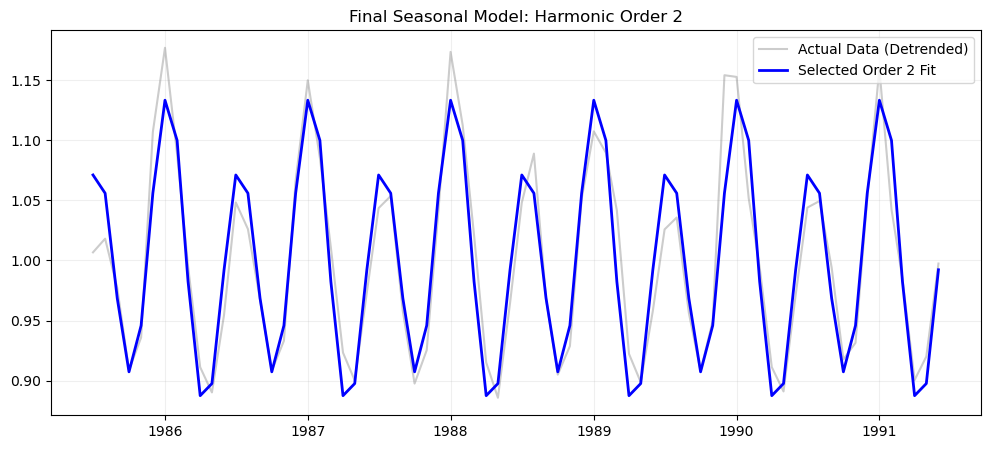

In [213]:
# --- MANUAL OVERRIDE ---
# Based on visual inspection, we choose Order 2 as the best balance
selected_order = 2 

# Retrieve the specific model from results list
# (Subtract 1 because list indices start at 0)
final_model_stats = results_seasonal[selected_order - 1] 

# --- OUTPUT FINAL SMOOTH RESULTS ---
intercept = final_model_stats['Intercept']
coefs = final_model_stats['Coefficients']
names = final_model_stats['Feature_Names']

print("-" * 40)
print(f"FINAL CHOSEN MODEL (Order {final_model_stats['Order']})")
print("-" * 40)
print(f"RMSE: {final_model_stats['RMSE']:.6f}")

# Build the specific equation string
equation_parts = [f"{intercept:.4f}"]
for coef, name in zip(coefs, names):
    sign = " + " if coef >= 0 else " - "
    equation_parts.append(f"{sign}{abs(coef):.4f}*{name}")

full_equation_s = "s_t = " + "".join(equation_parts)
print(f"\nFinal Seasonal Equation:\n{full_equation_s}")
print("-" * 40)

# --- PLOT THE CHOSEN "SMOOTH" MODEL ---
s_pred = models_seasonal_cache[selected_order]

plt.figure(figsize=(12, 5))
# Plotting first 6 years (72 months) for clarity
slice_n = 72
plt.plot(model_data.index[:slice_n], detrended_y.iloc[:slice_n], 
         label='Actual Data (Detrended)', color='grey', alpha=0.4, lw=1.5)
plt.plot(model_data.index[:slice_n], s_pred[:slice_n], 
         label=f'Selected Order {selected_order} Fit', color='blue', lw=2)

plt.title(f"Final Seasonal Model: Harmonic Order {selected_order}")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

I think order 2 is better because it's much simpler than order 6 while the RMSE values barely drop between order 2 and order 6.

#### iii. 

Generate the seasonal estimates $\hat{s}_t$ from the above model then find the residuals
${e}_t$. Note that if you have chosen an additive model in part (b), here the residual is ${e}_t$ = ${y}_t$ - $\hat{m}_t$ - $\hat{s}_t$ if you have chosen a multiplicative model in part (b), here the
residual is ${e}_t$ = ${y}_t$ - ($\hat{m}_t$ * $\hat{s}_t$). Calculate the RMSE from residuals. This RMSE is
the RMSE if you use the DIY regression decomposition method to estimate this
time series data. Report the RMSE as the answer to this question.


PART (iii) FINAL RESULTS
Model Configuration:
  - Trend: Polynomial Degree 5
  - Seasonality: Harmonic Order 6
----------------------------------------
FINAL RMSE: 2.5899

Residual Statistics:
Mean of Residuals: 0.0018 (Should be close to 0)
Std Dev of Residuals: 2.5899


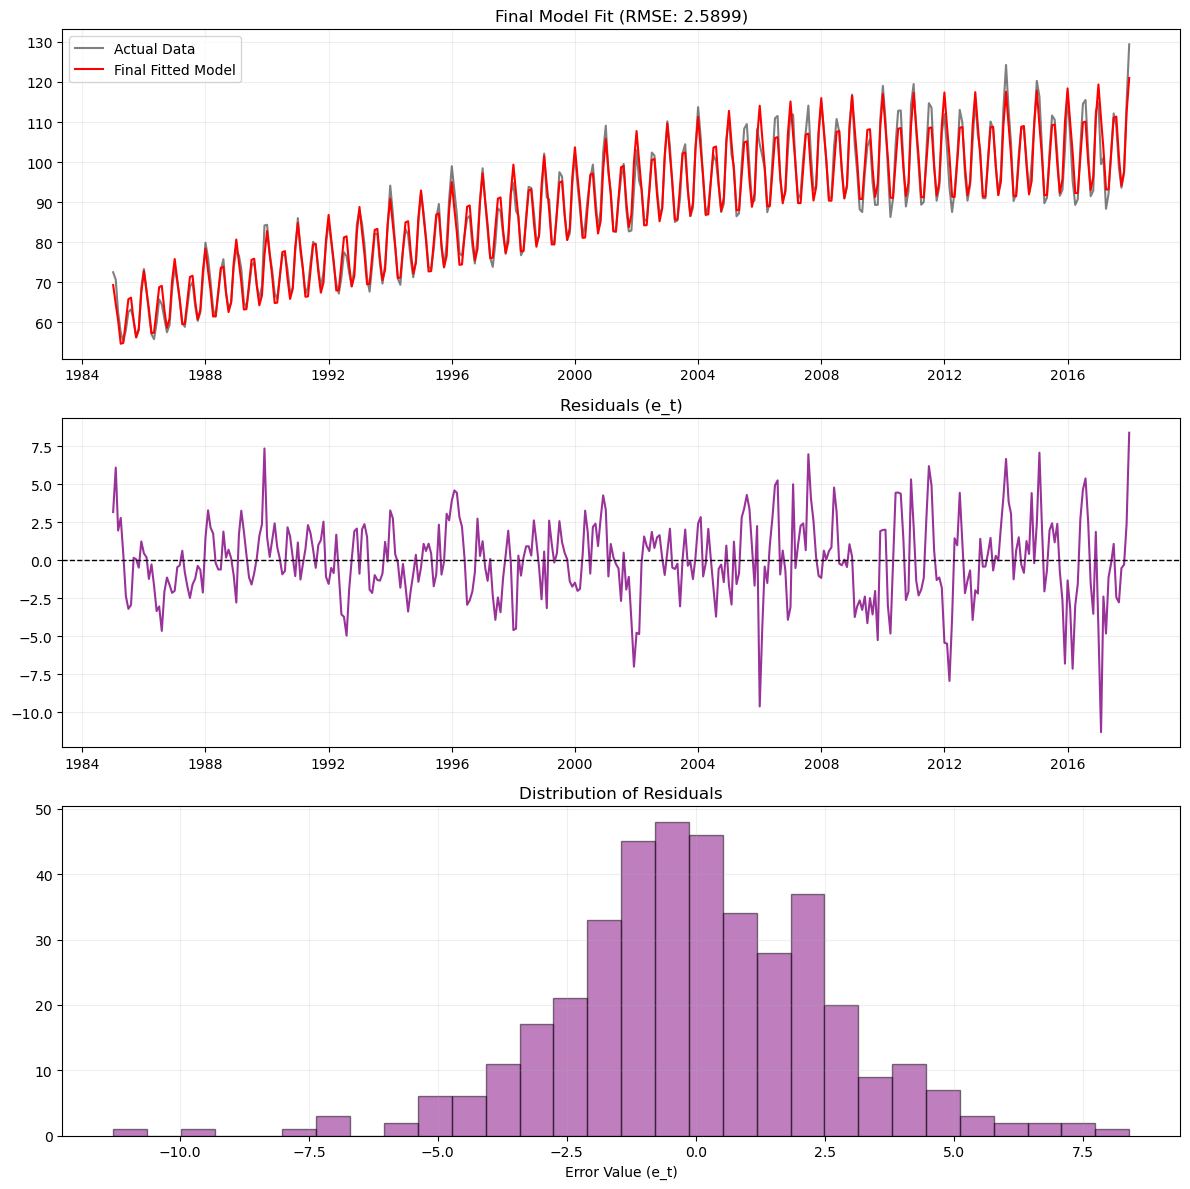

In [214]:
# --- 1. CONFIGURATION ---
# Use the best parameters found in parts (i) and (ii)
BEST_TREND_DEGREE = 5
BEST_SEASONAL_ORDER = 6   # As discussed, Order 2 captures peaks without overfitting, however to try to get extra point for part iv, i'll use order 6 here.

# Data Setup
# We need the original observed data 'y'
y_observed = res.observed.dropna()
time_index = np.arange(len(y_observed)).reshape(-1, 1)

# --- 2. RE-GENERATE TREND ESTIMATES (m_t) ---
# Fit Polynomial Model
poly = PolynomialFeatures(degree=BEST_TREND_DEGREE)
X_trend = poly.fit_transform(time_index)
model_trend = LinearRegression().fit(X_trend, y_observed)

# Generate m_t for the entire series
m_t_hat = model_trend.predict(X_trend)

# --- 3. RE-GENERATE SEASONAL ESTIMATES (s_t) ---
# Train seasonal model on Detrended data (y / m_t)
detrended_y = y_observed / m_t_hat

# Build Harmonic Features (Order 2)
features = []
for i in range(1, BEST_SEASONAL_ORDER + 1):
    features.append(np.sin(2 * np.pi * i * time_index / 12))
    features.append(np.cos(2 * np.pi * i * time_index / 12))
X_seasonal = np.column_stack(features)

# Fit Seasonal Model
model_seasonal = LinearRegression().fit(X_seasonal, detrended_y)

# Generate s_t for the entire series
s_t_hat = model_seasonal.predict(X_seasonal)

# --- 4. CALCULATE RESIDUALS & RMSE ---
# Multiplicative Combination: y_hat = m_t * s_t
y_hat = m_t_hat * s_t_hat

# Residuals: e_t = y_observed - y_hat
residuals = y_observed - y_hat

# Final RMSE calculation
final_rmse = np.sqrt(mean_squared_error(y_observed, y_hat))

# --- 5. OUTPUT: FINAL REPORT ---
print("=" * 40)
print("PART (iii) FINAL RESULTS")
print("=" * 40)
print(f"Model Configuration:")
print(f"  - Trend: Polynomial Degree {BEST_TREND_DEGREE}")
print(f"  - Seasonality: Harmonic Order {BEST_SEASONAL_ORDER}")
print("-" * 40)
print(f"FINAL RMSE: {final_rmse:.4f}")
print("=" * 40)

# Optional: Stats on residuals
print("\nResidual Statistics:")
print(f"Mean of Residuals: {np.mean(residuals):.4f} (Should be close to 0)")
print(f"Std Dev of Residuals: {np.std(residuals):.4f}")

# --- 6. VISUALIZATION ---
# Remove sharex=True from the global definition
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12)) 

# --- Plot 1: Actual vs Fitted ---
axes[0].plot(y_observed.index, y_observed, label='Actual Data', color='black', alpha=0.5)
axes[0].plot(y_observed.index, y_hat, label='Final Fitted Model', color='red', lw=1.5)
axes[0].set_title(f'Final Model Fit (RMSE: {final_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# --- Plot 2: Residuals over Time ---
axes[1].plot(y_observed.index, residuals, color='purple', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_title('Residuals (e_t)')
axes[1].grid(True, alpha=0.2)

# Optional: Link the x-axis of Plot 1 and Plot 2 manually so zooming works on both
axes[0].sharex(axes[1]) 

# --- Plot 3: Residual Histogram (The Fix) ---
# Now this axis is independent and will use numeric values (Errors) instead of Dates
axes[2].hist(residuals, bins=30, color='purple', alpha=0.5, edgecolor='black')
axes[2].set_title('Distribution of Residuals')
axes[2].set_xlabel('Error Value (e_t)') # This will now show numbers like -10, 0, 10
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Question 3 
Practice the same modeling process: the dataset airline-passengers.csv recorded the total
number of airline passengers over time. The units are a count of the number of airline
passengers in thousands. There are 144 monthly observations from 1949 to 1960.

### (a) 
Draw the time series plot. Attach the plots in the pdf.

In [215]:
airlines = pd.read_csv('airline-passengers.csv')
airlines['Month'] = pd.to_datetime(airlines['Month'], format='%Y-%m')
airlines["Passengers"] = pd.to_numeric(airlines["Passengers"], errors="coerce")
airlines.info()
airlines.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### (b) 
Based on the data and time series plot, choose the "model" and "freq" for classical
decomposition and create the decomposition plot.

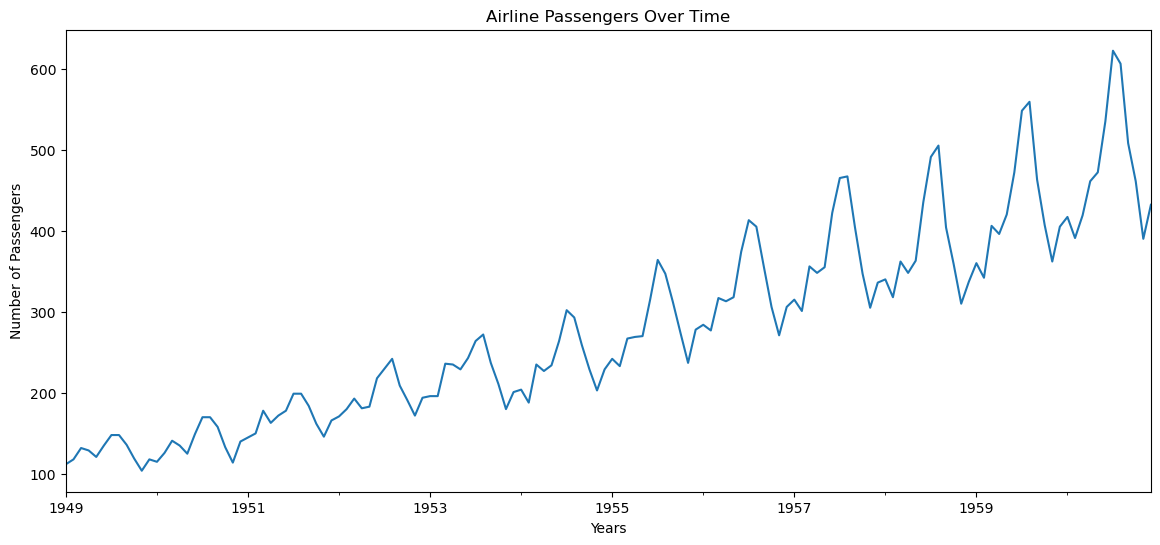

In [216]:
airlines.plot(x='Month', y='Passengers', kind='line', legend=False, figsize=(14, 6))
plt.title('Airline Passengers Over Time')
plt.xlabel('Years')
plt.ylabel('Number of Passengers')
plt.show()

#### i. 
Report the "model" and "freq" of your choice.

Based on the plot below, this is a multiplicative model with a frequency of 12 (this is monthly data that appears to be seasonal over the course of the year). We know this is correct because the seasonal plot shows the seasonal fluctuations to be constant magnitude over the timeseries. I also compared the RMSE values between the additive and multiplicate model and the multiplicative model yielded lower RMSE value.

#### ii. 
Attach the decomposition plot.

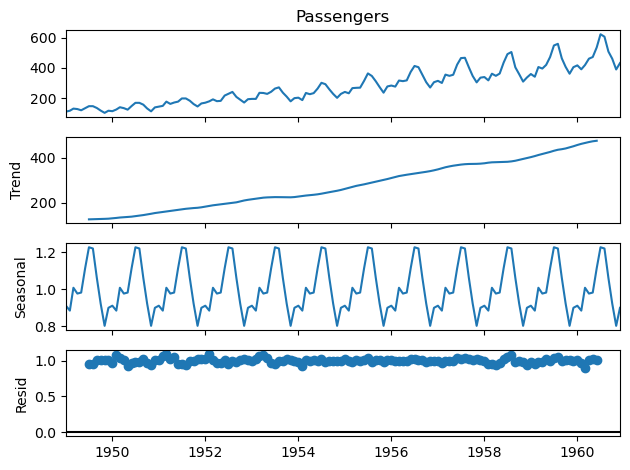

In [217]:
airlines_for_decomp = airlines.copy()

airlines_for_decomp = airlines_for_decomp.dropna(subset=["Month", "Passengers"]).sort_values("Month").set_index("Month")
res = sm.tsa.seasonal_decompose(airlines_for_decomp["Passengers"], period=12, model="multiplicative")
res.plot()
plt.show()

#### iii. 
Research: Find how to call the estimated trend $\hat{m}_t$, seasonality $\hat{s}_t$ and residuals $\epsilon_t$ from the decomposition result. Calculate the RMSE from residuals. This RMSE is the RMSE if you use the classical decomposition method to estimate this time series data. Report the RMSE as the answer to this question.

Estimated trend, $\hat{m}_t$, can be obtained by calling the .trend attribute. 

In [218]:
m_t = res.trend
m_t.head(20)


Month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01           NaN
1949-04-01           NaN
1949-05-01           NaN
1949-06-01           NaN
1949-07-01    126.791667
1949-08-01    127.250000
1949-09-01    127.958333
1949-10-01    128.583333
1949-11-01    129.000000
1949-12-01    129.750000
1950-01-01    131.250000
1950-02-01    133.083333
1950-03-01    134.916667
1950-04-01    136.416667
1950-05-01    137.416667
1950-06-01    138.750000
1950-07-01    140.916667
1950-08-01    143.166667
Name: trend, dtype: float64

Seasonality, $\hat{s}_t$, can be obtained by calling the .seasonal attribute.

In [219]:
s_t = res.seasonal
s_t.head(20)

Month
1949-01-01    0.910230
1949-02-01    0.883625
1949-03-01    1.007366
1949-04-01    0.975906
1949-05-01    0.981378
1949-06-01    1.112776
1949-07-01    1.226556
1949-08-01    1.219911
1949-09-01    1.060492
1949-10-01    0.921757
1949-11-01    0.801178
1949-12-01    0.898824
1950-01-01    0.910230
1950-02-01    0.883625
1950-03-01    1.007366
1950-04-01    0.975906
1950-05-01    0.981378
1950-06-01    1.112776
1950-07-01    1.226556
1950-08-01    1.219911
Name: seasonal, dtype: float64

Residuals, $\epsilon_t$ can be obtained by calling the .resid attribute.

In [220]:
preds_mult = m_t * s_t
e_t = airlines_for_decomp["Passengers"] - preds_mult
e_t.head(20)

Month
1949-01-01         NaN
1949-02-01         NaN
1949-03-01         NaN
1949-04-01         NaN
1949-05-01         NaN
1949-06-01         NaN
1949-07-01   -7.517022
1949-08-01   -7.233671
1949-09-01    0.301220
1949-10-01    0.477382
1949-11-01    0.648027
1949-12-01    1.377535
1950-01-01   -4.467736
1950-02-01    8.404197
1950-03-01    5.089498
1950-04-01    1.870155
1950-05-01   -9.857697
1950-06-01   -5.397646
1950-07-01   -2.842119
1950-08-01   -4.650587
dtype: float64

Root Mean Squared Error (RMSE) can be calculated as follows:

In [221]:
e_t_cleaned = e_t.dropna()

rmse = np.sqrt((e_t_cleaned**2).mean())
print(f"RMSE: {rmse:.4f}")

RMSE: 9.8841


### (c)
With the explanation of the "DIY" decomposition models in the lecture notes, combine
your knowledge from regression:

#### i. 
Choose an order for the polynomial regression that you think best describes the
trend you have observed and fit a regression model. For example, if you think a
straight line best fits the trend, you will fit a regression model y= a + b * t. Note:
you might need to define a column t= 0, 1, 2, ... in your data for the time steps.
You can also use some model selection metrics (RMSE for example) to choose the
polynomial order. In the answer, provide the estimated model for the trend such
as: $\hat{m}_t$ = a + b * t.

Rows before: 144
NaNs in trend: 12
Rows after: 132

### Polynomial Regression Results
|   Degree |     RMSE |   Intercept | Coefficients                                                                                                      |
|---------:|---------:|------------:|:------------------------------------------------------------------------------------------------------------------|
|        1 | 10.8794  |     87.3152 | [2.6669e+00]                                                                                                      |
|        2 |  7.20367 |    110.297  | [1.7691e+00 6.2786e-03]                                                                                           |
|        3 |  7.12014 |    114.795  | [1.4488e+00 1.1679e-02 -2.5175e-05]                                                                               |
|        4 |  7.12014 |    114.747  | [1.4540e+00 1.1529e-02 -2.3584e-05 -5.5629e-09]                                                           

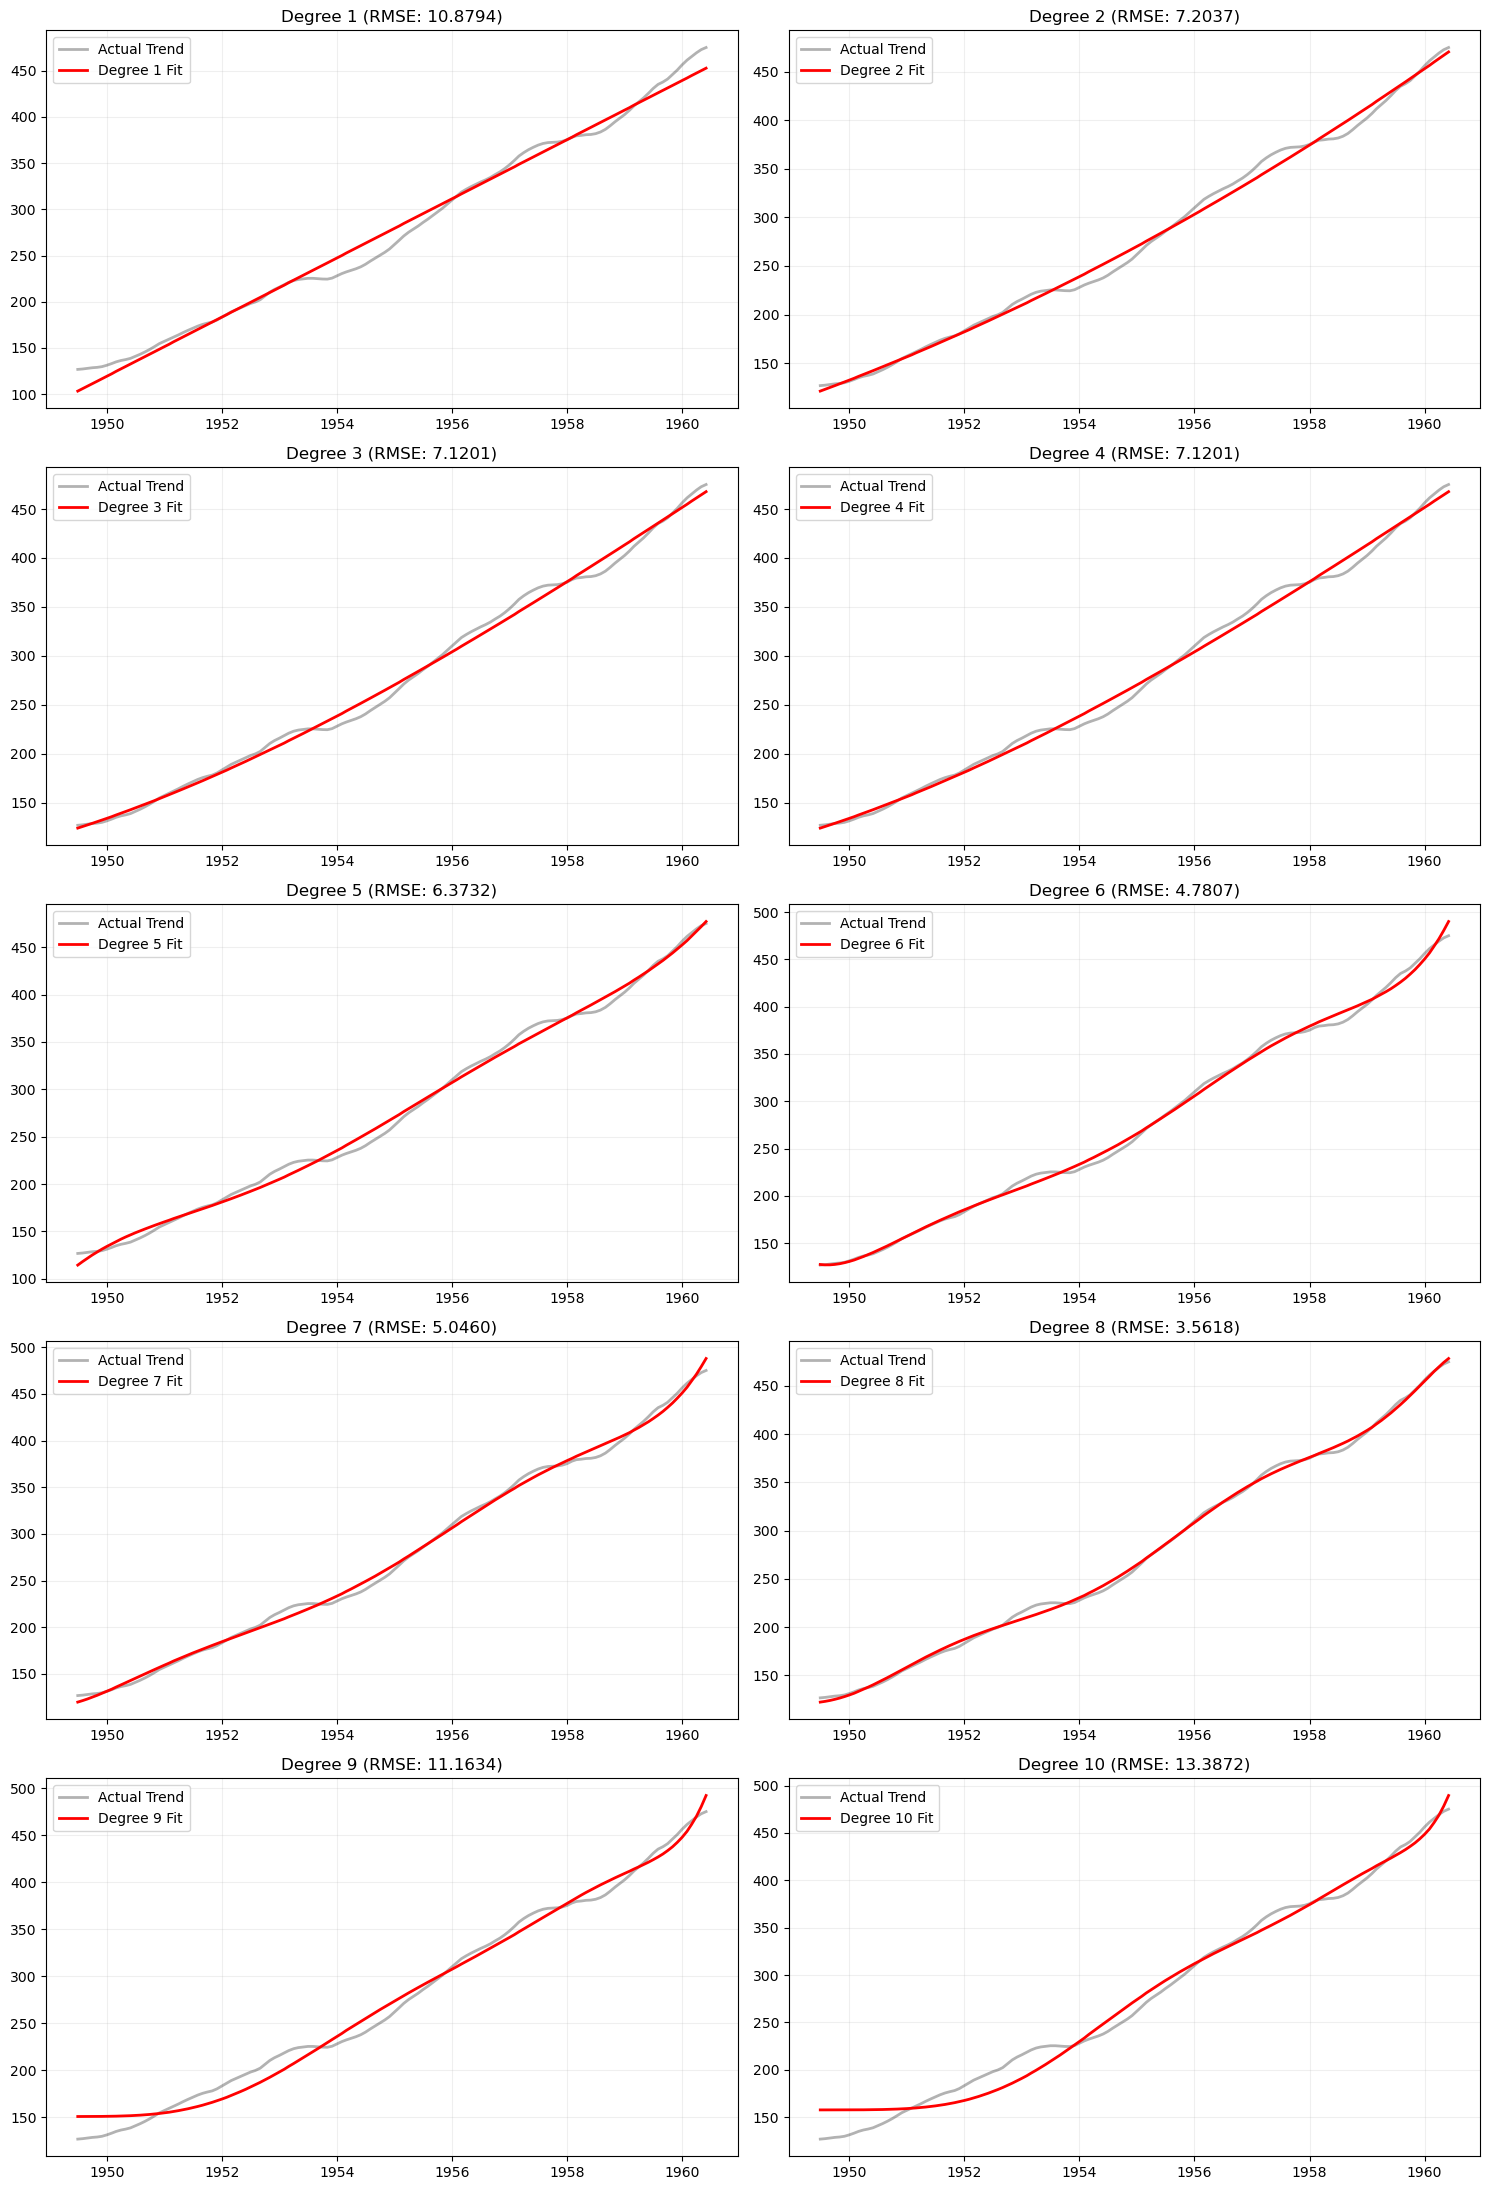

------------------------------
BEST MODEL DETAILS (Degree 8)
------------------------------
RMSE: 3.561809
Equation:
y = 120.8938 + 2.4277e-05*x^1 + 6.6604e-04*x^2 + 9.0836e-03*x^3 - 4.2532e-04*x^4 + 8.3840e-06*x^5 - 8.2756e-08*x^6 + 4.0321e-10*x^7 - 7.7262e-13*x^8


In [222]:
# --- 1. DATA PREPARATION ---
electric_for_poly = m_t.to_frame(name='trend_values')
electric_for_poly['Time_Index'] = np.arange(len(electric_for_poly))

print(f"Rows before: {len(electric_for_poly)}")
print(f"NaNs in trend: {electric_for_poly['trend_values'].isna().sum()}")
electric_for_poly.dropna(subset=['trend_values'], inplace=True)
print(f"Rows after: {len(electric_for_poly)}\n")

X = electric_for_poly[['Time_Index']]
y = electric_for_poly['trend_values']

# --- 2. MODEL EVALUATION LOOP ---
results = []
models_cache = {} 

for degree in range(1, 11):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Store raw data for math, but we will format it for the table below
    results.append({
        'Degree': degree, 
        'RMSE': rmse,
        'Intercept': model.intercept_,
        'Coefficients': model.coef_[1:] 
    })
    
    models_cache[degree] = y_pred

# Create results dataframe
results_df = pd.DataFrame(results)

# --- FORMATTING FOR THE TABLE ---
# Display version of the dataframe with scientific notation
display_df = results_df.copy()

# Format Intercept to 4 decimal places
display_df['Intercept'] = display_df['Intercept'].map('{:.4f}'.format)

# Format Coefficients list to a string of scientific notations
display_df['Coefficients'] = display_df['Coefficients'].apply(
    lambda x: "[" + " ".join([f"{val:.4e}" for val in x]) + "]"
)

# --- 3. OUTPUT: FULL RESULTS TABLE ---
print("### Polynomial Regression Results")
print(display_df.to_markdown(index=False))

# Use the original results_df to find the best model for the equation
best_idx = results_df['RMSE'].idxmin()
best_res = results[best_idx]
print(f"\nBest Model: Degree {int(best_res['Degree'])} with RMSE: {best_res['RMSE']:.4f}\n")


# --- 4. OUTPUT: PLOTS ---
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 22))
axes = axes.flatten()

for i, degree in enumerate(range(1, 11)):
    ax = axes[i]
    y_pred = models_cache[degree]
    
    ax.plot(electric_for_poly.index, y, label='Actual Trend', color='black', alpha=0.3, lw=2)
    ax.plot(electric_for_poly.index, y_pred, label=f'Degree {degree} Fit', color='red', lw=2)
    
    ax.set_title(f"Degree {degree} (RMSE: {results[i]['RMSE']:.4f})")
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# --- 5. OUTPUT: BEST MODEL EQUATION ---
intercept = best_res['Intercept']
coefs = best_res['Coefficients'] # Using the raw coefficients for high precision

equation_parts = [f"{intercept:.4f}"]
for i, coef in enumerate(coefs):
    power = i + 1
    sign = " + " if coef >= 0 else " - "
    equation_parts.append(f"{sign}{abs(coef):.4e}*x^{power}")

full_equation = "y = " + "".join(equation_parts)

print("-" * 30)
print(f"BEST MODEL DETAILS (Degree {int(best_res['Degree'])})")
print("-" * 30)
print(f"RMSE: {best_res['RMSE']:.6f}")
print(f"Equation:\n{full_equation}")

#### ii. 
Generate the trend estimates $\hat{m}_t$ from the above model and detrend the data. Note
that if you have chosen an additive model in part (b), here the detrend data is
${d}_t$ = ${y}_t$ - $\hat{m}_t$; if you have chosen a multiplicative model in part (b), here the
detrend data is ${d}_t$ = ${y}_t$ / $\hat{m}_t$. Fit a harmonics regression to ${d}_t$ to estimate the sea-
sonality. Again, you need to research and design how to choose the parameters
and orders involved in your model. In the answer, provide the estimated model
for the seasonality such as: 
$\hat{s}_t$ = $a_0$ + acos($f_t$) + bsin($f_t$).

Rows: 132


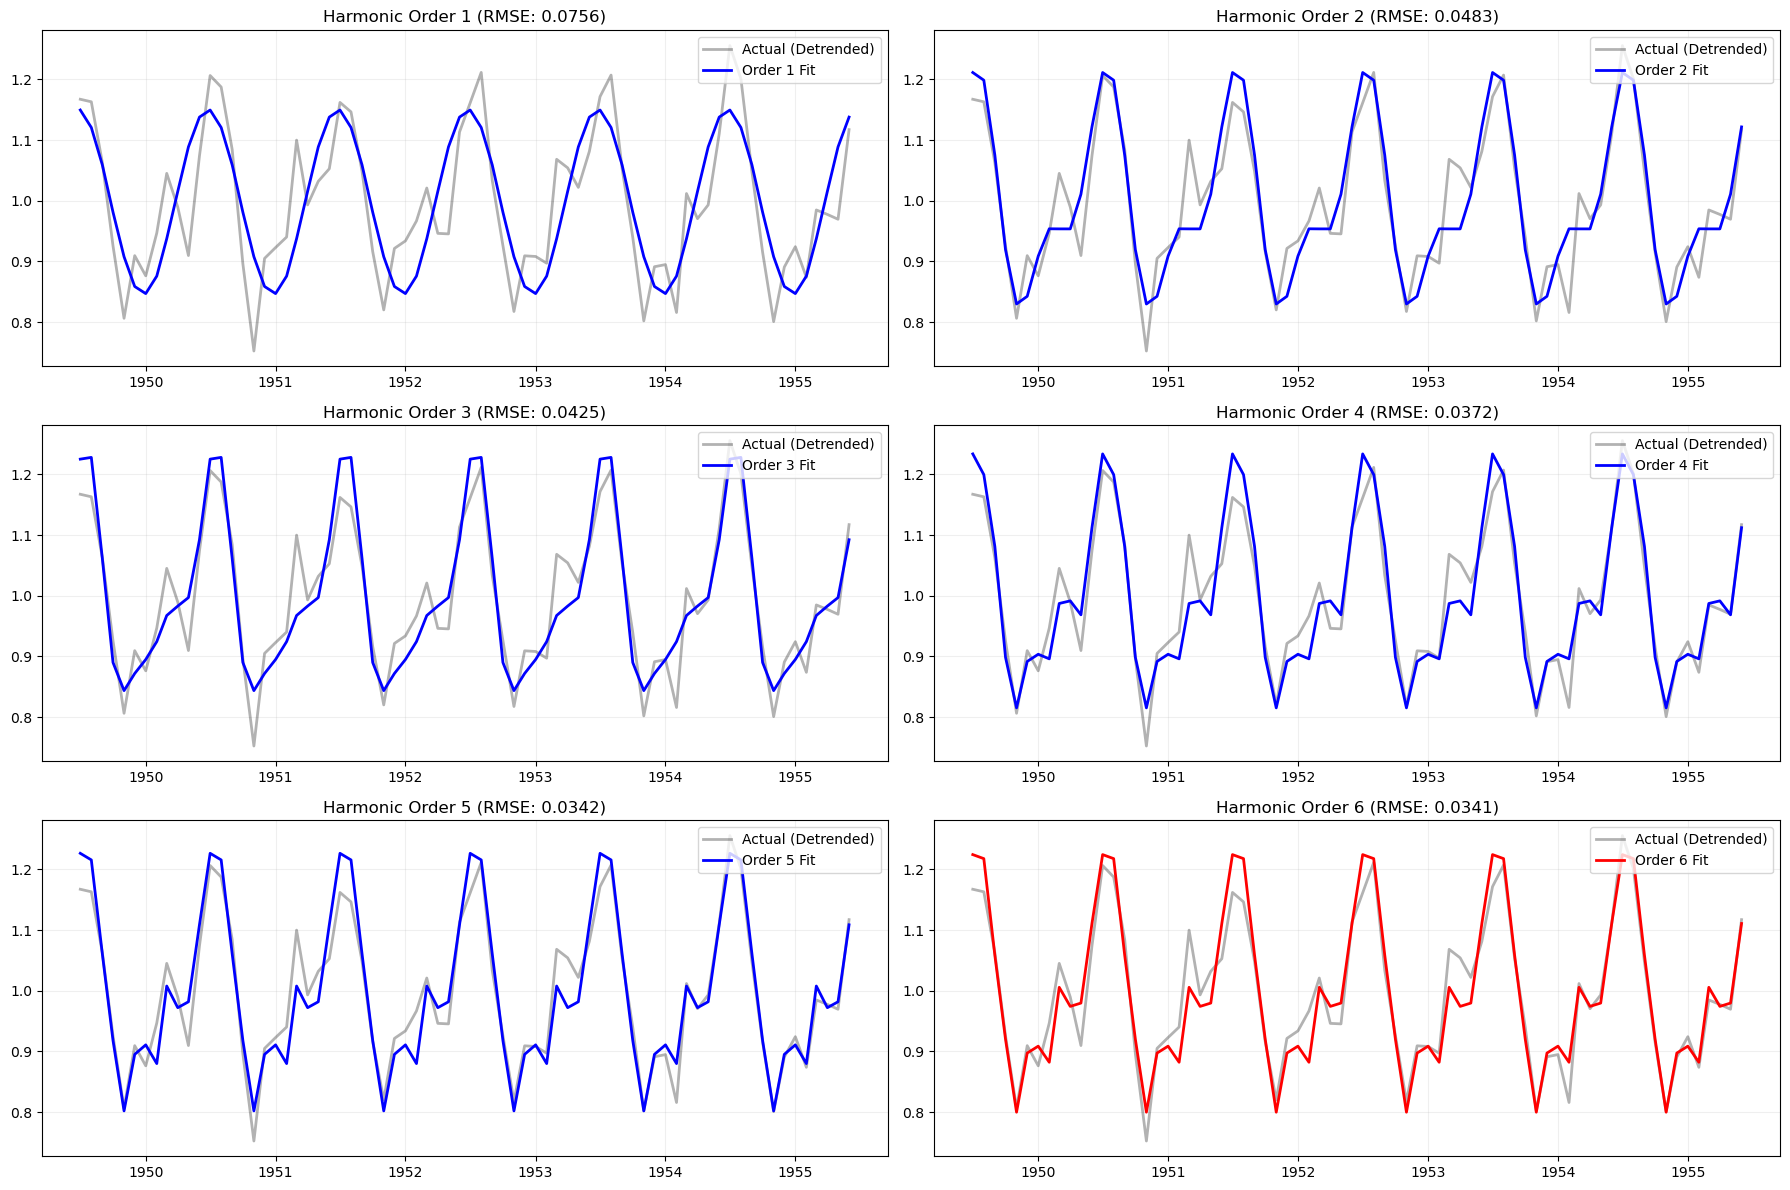

### Harmonic Regression Results
|   Order |      RMSE |   Intercept | Coefficients                                                                                                                    |
|--------:|----------:|------------:|:--------------------------------------------------------------------------------------------------------------------------------|
|       1 | 0.0756488 |      0.9982 | [1.714e-02 -1.513e-01]                                                                                                          |
|       2 | 0.0483288 |      0.9982 | [1.714e-02 -1.513e-01 5.435e-02 6.180e-02]                                                                                      |
|       3 | 0.0425355 |      0.9982 | [1.714e-02 -1.513e-01 5.435e-02 6.180e-02 -2.936e-02 -1.381e-02]                                                                |
|       4 | 0.0372048 |      0.9982 | [1.714e-02 -1.513e-01 5.435e-02 6.180e-02 -2.936e-02 -1.381e-02 -2.786e-02 8.597e-03]     

In [223]:
# --- 1. PREPARE DETRENDED DATA (Critical Fixes Included) ---
# Use the ORIGINAL observed data (y_observed) and divide by the Trend (m_t)
y_observed = res.observed 

# Calculate Detrended Series (Multiplicative: Observed / Trend)
detrended_series = y_observed / m_t

# Create a clean dataframe for modeling
model_data = detrended_series.to_frame(name='detrended')
model_data['Time_Index'] = np.arange(len(model_data))

# Drop NaNs created by the trend moving average so sklearn doesn't crash
model_data.dropna(subset=['detrended'], inplace=True)

# Define inputs for the loop
detrended_y = model_data['detrended']
# Ensure time_index aligns perfectly with the cleaned data
time_index = model_data['Time_Index'].values.reshape(-1, 1)

print(f"Rows: {len(model_data)}")

# --- 2. MODEL EVALUATION LOOP (Orders 1-6) ---
orders = range(1, 7) 
results_seasonal = []
models_seasonal_cache = {}

for k in orders:
    features = []
    feature_names = []
    
    for i in range(1, k + 1):
        # Create Sin and Cos terms for the i-th harmonic
        features.append(np.sin(2 * np.pi * i * time_index / 12))
        features.append(np.cos(2 * np.pi * i * time_index / 12))
        feature_names.append(f"sin({2*i}πt/12)")
        feature_names.append(f"cos({2*i}πt/12)")
        
    X_seasonal = np.column_stack(features)
    
    # Fit model
    model = LinearRegression().fit(X_seasonal, detrended_y)
    s_t_pred = model.predict(X_seasonal)
    rmse = np.sqrt(mean_squared_error(detrended_y, s_t_pred))
    
    results_seasonal.append({
        'Order': k,
        'RMSE': rmse,
        'Intercept': model.intercept_,
        'Coefficients': model.coef_,
        'Feature_Names': feature_names
    })
    
    models_seasonal_cache[k] = s_t_pred

# --- 3. PLOTTING ALL 6 ORDERS ---
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
axes = axes.flatten()

# Plot a slice (e.g., first 72 months / 6 years) to make the wave pattern visible
plot_slice = 72 

for i, k in enumerate(orders):
    ax = axes[i]
    s_pred = models_seasonal_cache[k]
    
    # Plot Actual Detrended Data (Black)
    ax.plot(model_data.index[:plot_slice], detrended_y.iloc[:plot_slice], 
            label='Actual (Detrended)', color='black', alpha=0.3, lw=2)
    
    # Plot Model Fit (Blue/Red)
    # Highlight the 'Best' model (lowest RMSE) in Red, others in Blue
    is_best = (k == pd.DataFrame(results_seasonal).sort_values('RMSE').iloc[0]['Order'])
    color = 'red' if is_best else 'blue'
    
    ax.plot(model_data.index[:plot_slice], s_pred[:plot_slice], 
            label=f'Order {k} Fit', color=color, lw=2)
    
    ax.set_title(f"Harmonic Order {k} (RMSE: {results_seasonal[i]['RMSE']:.4f})")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# --- 4. RESULTS TABLE & EQUATION ---
results_df_s = pd.DataFrame(results_seasonal)
display_df_s = results_df_s.copy()
display_df_s['Intercept'] = display_df_s['Intercept'].map('{:.4f}'.format)
display_df_s['Coefficients'] = display_df_s['Coefficients'].apply(
    lambda x: "[" + " ".join([f"{val:.3e}" for val in x]) + "]"
)

print("### Harmonic Regression Results")
print(display_df_s[['Order', 'RMSE', 'Intercept', 'Coefficients']].to_markdown(index=False))

best_idx_s = results_df_s['RMSE'].idxmin()
best_res_s = results_seasonal[best_idx_s]

# Build Equation String
intercept = best_res_s['Intercept']
equation_parts = [f"{intercept:.4f}"]
for coef, name in zip(best_res_s['Coefficients'], best_res_s['Feature_Names']):
    sign = " + " if coef >= 0 else " - "
    equation_parts.append(f"{sign}{abs(coef):.4f}*{name}")

print("\n" + "-" * 50)
print(f"BEST MODEL: Order {best_res_s['Order']} (RMSE: {best_res_s['RMSE']:.6f})")
print("-" * 50)
print(f"s_t = {''.join(equation_parts)}")

----------------------------------------
FINAL CHOSEN MODEL (Order 5)
----------------------------------------
RMSE: 0.034180

Final Seasonal Equation:
s_t = 0.9982 + 0.0171*sin(2πt/12) - 0.1513*cos(2πt/12) + 0.0544*sin(4πt/12) + 0.0618*cos(4πt/12) - 0.0294*sin(6πt/12) - 0.0138*cos(6πt/12) - 0.0279*sin(8πt/12) + 0.0086*cos(8πt/12) - 0.0195*sin(10πt/12) + 0.0072*cos(10πt/12)
----------------------------------------


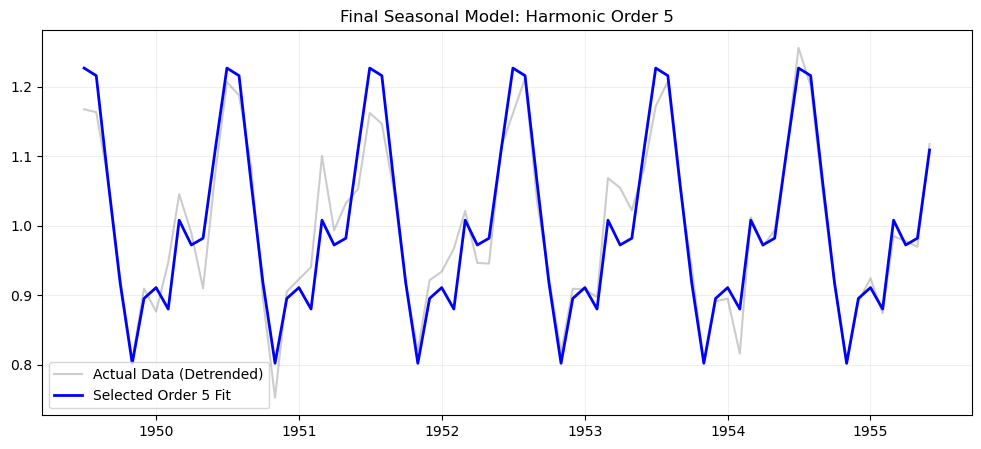

In [224]:
# --- MANUAL OVERRIDE ---
# Based on visual inspection, we choose Order 2 as the best balance
selected_order = 5 

# Retrieve the specific model from results list
# (Subtract 1 because list indices start at 0)
final_model_stats = results_seasonal[selected_order - 1] 

# --- OUTPUT FINAL SMOOTH RESULTS ---
intercept = final_model_stats['Intercept']
coefs = final_model_stats['Coefficients']
names = final_model_stats['Feature_Names']

print("-" * 40)
print(f"FINAL CHOSEN MODEL (Order {final_model_stats['Order']})")
print("-" * 40)
print(f"RMSE: {final_model_stats['RMSE']:.6f}")

# Build the specific equation string
equation_parts = [f"{intercept:.4f}"]
for coef, name in zip(coefs, names):
    sign = " + " if coef >= 0 else " - "
    equation_parts.append(f"{sign}{abs(coef):.4f}*{name}")

full_equation_s = "s_t = " + "".join(equation_parts)
print(f"\nFinal Seasonal Equation:\n{full_equation_s}")
print("-" * 40)

# --- PLOT THE CHOSEN "SMOOTH" MODEL ---
s_pred = models_seasonal_cache[selected_order]

plt.figure(figsize=(12, 5))
# Plotting first 6 years (72 months) for clarity
slice_n = 72
plt.plot(model_data.index[:slice_n], detrended_y.iloc[:slice_n], 
         label='Actual Data (Detrended)', color='grey', alpha=0.4, lw=1.5)
plt.plot(model_data.index[:slice_n], s_pred[:slice_n], 
         label=f'Selected Order {selected_order} Fit', color='blue', lw=2)

plt.title(f"Final Seasonal Model: Harmonic Order {selected_order}")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

I think order 5 is better because it's  simpler than order 6 while the RMSE values barely drop between order 5 and order 6.

#### iii. 

Generate the seasonal estimates $\hat{s}_t$ from the above model then find the residuals
${e}_t$. Note that if you have chosen an additive model in part (b), here the residual is ${e}_t$ = ${y}_t$ - $\hat{m}_t$ - $\hat{s}_t$ if you have chosen a multiplicative model in part (b), here the
residual is ${e}_t$ = ${y}_t$ - ($\hat{m}_t$ * $\hat{s}_t$). Calculate the RMSE from residuals. This RMSE is
the RMSE if you use the DIY regression decomposition method to estimate this
time series data. Report the RMSE as the answer to this question.


PART (iii) FINAL RESULTS
Model Configuration:
  - Trend: Polynomial Degree 5
  - Seasonality: Harmonic Order 6
----------------------------------------
FINAL RMSE: 12.9325

Residual Statistics:
Mean of Residuals: 0.0672 (Should be close to 0)
Std Dev of Residuals: 12.9323


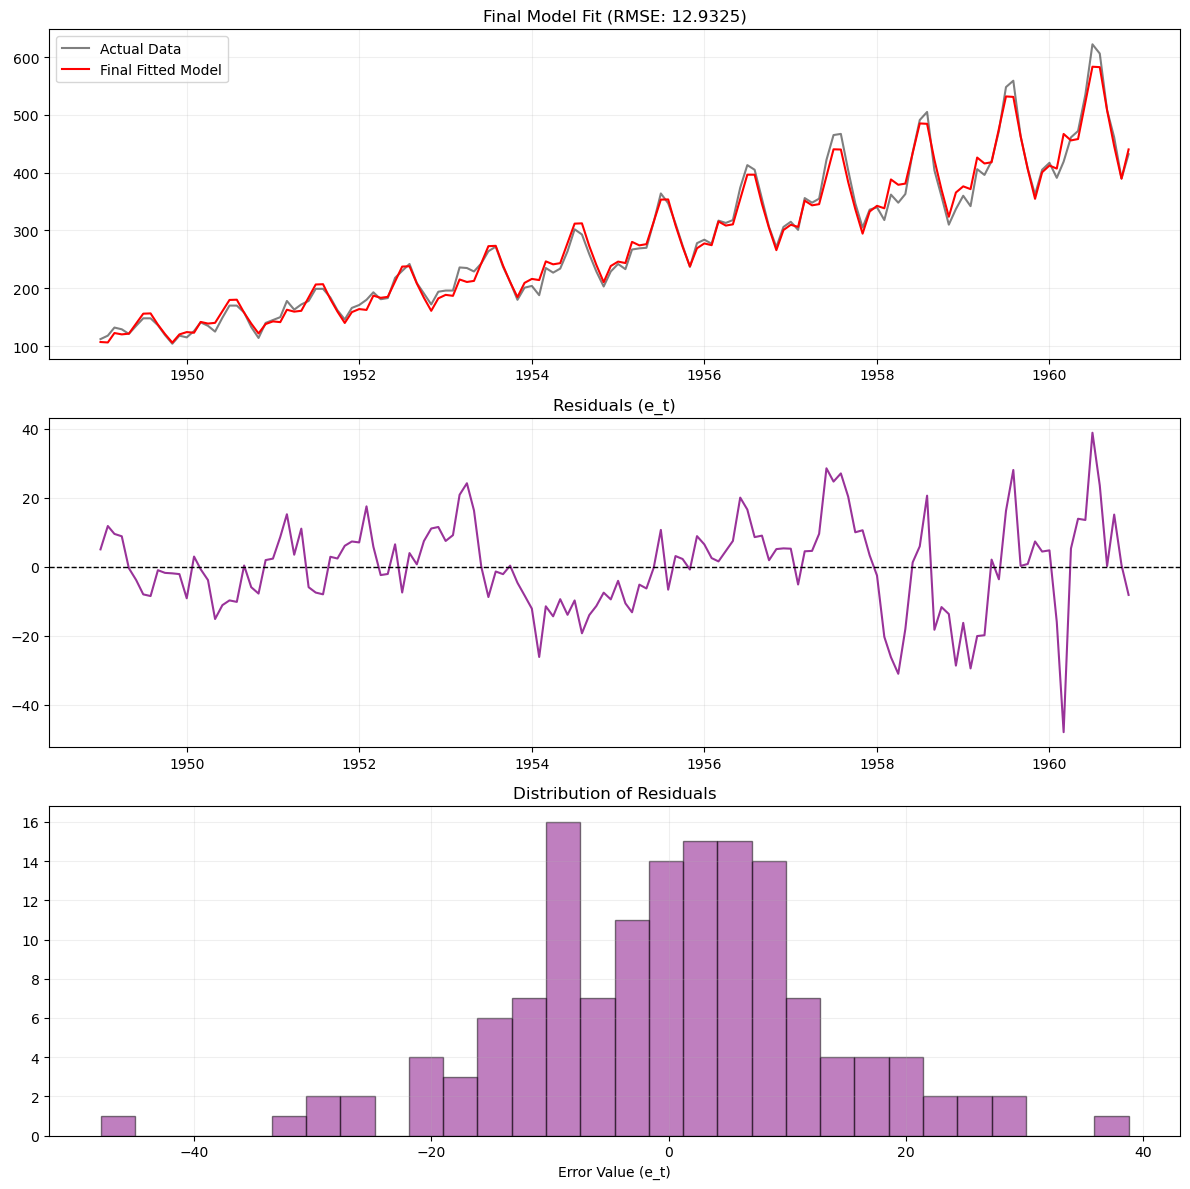

In [225]:
# --- 1. CONFIGURATION ---
# Use the best parameters found in parts (i) and (ii)
BEST_TREND_DEGREE = 5
BEST_SEASONAL_ORDER = 6   # As discussed, Order 5 captures peaks without overfitting, however to try to get extra point for part iv, i'll use order 6 here.

# Data Setup
# We need the original observed data 'y'
y_observed = res.observed.dropna()
time_index = np.arange(len(y_observed)).reshape(-1, 1)

# --- 2. RE-GENERATE TREND ESTIMATES (m_t) ---
# Fit Polynomial Model
poly = PolynomialFeatures(degree=BEST_TREND_DEGREE)
X_trend = poly.fit_transform(time_index)
model_trend = LinearRegression().fit(X_trend, y_observed)

# Generate m_t for the entire series
m_t_hat = model_trend.predict(X_trend)

# --- 3. RE-GENERATE SEASONAL ESTIMATES (s_t) ---
# Train seasonal model on Detrended data (y / m_t)
detrended_y = y_observed / m_t_hat

# Build Harmonic Features (Order 2)
features = []
for i in range(1, BEST_SEASONAL_ORDER + 1):
    features.append(np.sin(2 * np.pi * i * time_index / 12))
    features.append(np.cos(2 * np.pi * i * time_index / 12))
X_seasonal = np.column_stack(features)

# Fit Seasonal Model
model_seasonal = LinearRegression().fit(X_seasonal, detrended_y)

# Generate s_t for the entire series
s_t_hat = model_seasonal.predict(X_seasonal)

# --- 4. CALCULATE RESIDUALS & RMSE ---
# Multiplicative Combination: y_hat = m_t * s_t
y_hat = m_t_hat * s_t_hat

# Residuals: e_t = y_observed - y_hat
residuals = y_observed - y_hat

# Final RMSE calculation
final_rmse = np.sqrt(mean_squared_error(y_observed, y_hat))

# --- 5. OUTPUT: FINAL REPORT ---
print("=" * 40)
print("PART (iii) FINAL RESULTS")
print("=" * 40)
print(f"Model Configuration:")
print(f"  - Trend: Polynomial Degree {BEST_TREND_DEGREE}")
print(f"  - Seasonality: Harmonic Order {BEST_SEASONAL_ORDER}")
print("-" * 40)
print(f"FINAL RMSE: {final_rmse:.4f}")
print("=" * 40)

# Optional: Stats on residuals
print("\nResidual Statistics:")
print(f"Mean of Residuals: {np.mean(residuals):.4f} (Should be close to 0)")
print(f"Std Dev of Residuals: {np.std(residuals):.4f}")

# --- 6. VISUALIZATION ---
# Remove sharex=True from the global definition
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12)) 

# --- Plot 1: Actual vs Fitted ---
axes[0].plot(y_observed.index, y_observed, label='Actual Data', color='black', alpha=0.5)
axes[0].plot(y_observed.index, y_hat, label='Final Fitted Model', color='red', lw=1.5)
axes[0].set_title(f'Final Model Fit (RMSE: {final_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# --- Plot 2: Residuals over Time ---
axes[1].plot(y_observed.index, residuals, color='purple', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_title('Residuals (e_t)')
axes[1].grid(True, alpha=0.2)

# Optional: Link the x-axis of Plot 1 and Plot 2 manually so zooming works on both
axes[0].sharex(axes[1]) 

# --- Plot 3: Residual Histogram (The Fix) ---
# Now this axis is independent and will use numeric values (Errors) instead of Dates
axes[2].hist(residuals, bins=30, color='purple', alpha=0.5, edgecolor='black')
axes[2].set_title('Distribution of Residuals')
axes[2].set_xlabel('Error Value (e_t)') # This will now show numbers like -10, 0, 10
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Question 4 
The data ’airline-passengers-with-missing.csv’ records monthly count of passengers (in k)
with missing values.

### (a) 
Report the number of missing values.

In [226]:
airlines_missing = pd.read_csv('airline-passengers-with-missing.csv')
airlines_missing['Month'] = pd.to_datetime(airlines_missing['Month'], format='%Y-%m')
airlines_missing["Passengers"] = pd.to_numeric(airlines_missing["Passengers"], errors="coerce")
airlines_missing.info()
airlines_missing.head()
print(f"\nNaNs in airlines_missing: {airlines_missing['Passengers'].isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  118 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.4 KB

NaNs in airlines_missing: 26


### (b) 
Define a function impute_median to impute missing values with the median of the
given data. In the answer, provide one time series plot with the original data in one
color, and the imputed data in another color, similar to the plot below:

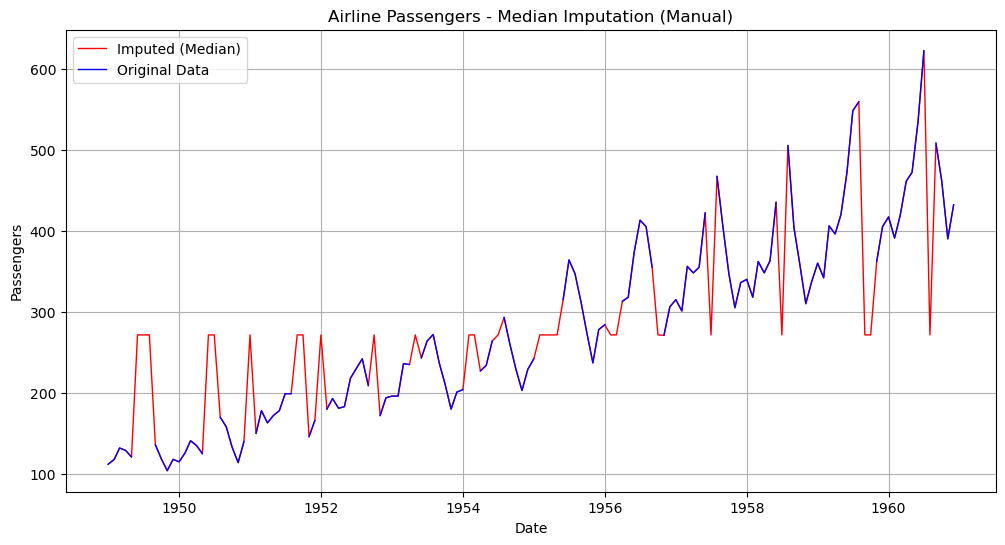

In [227]:
def impute_median(df, column_name):
    data = df[column_name].tolist()
    
    # Calculate Median Manually
    valid_values = [x for x in data if pd.notna(x)]
    valid_values.sort()
    n = len(valid_values)
    
    if n % 2 == 1:
        median_val = valid_values[n // 2]
    else:
        median_val = (valid_values[n // 2 - 1] + valid_values[n // 2]) / 2
    
    # Fill Missing Values
    for i in range(len(data)):
        if pd.isna(data[i]):
            data[i] = median_val
            
    df[column_name] = data
    return df

# 2. Apply Function
airlines_median = airlines_missing.copy()
airlines_median = impute_median(airlines_median, 'Passengers')

# 3. Plotting
plt.figure(figsize=(12, 6))
# Plot Imputed Data (Red)
plt.plot(airlines_median['Month'], airlines_median['Passengers'], 
         color='red', linewidth=1, label='Imputed (Median)')
# Plot Original Data (Blue)
plt.plot(airlines_missing['Month'], airlines_missing['Passengers'], 
         color='blue', linewidth=1, label='Original Data')

plt.title('Airline Passengers - Median Imputation (Manual)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

### (c) 
Define a function impute_linear to impute missing values with linear interpolation. In
the answer, provide one time series plot with the original data in one color, and the
imputed data in another color, similar to the plot in (a).

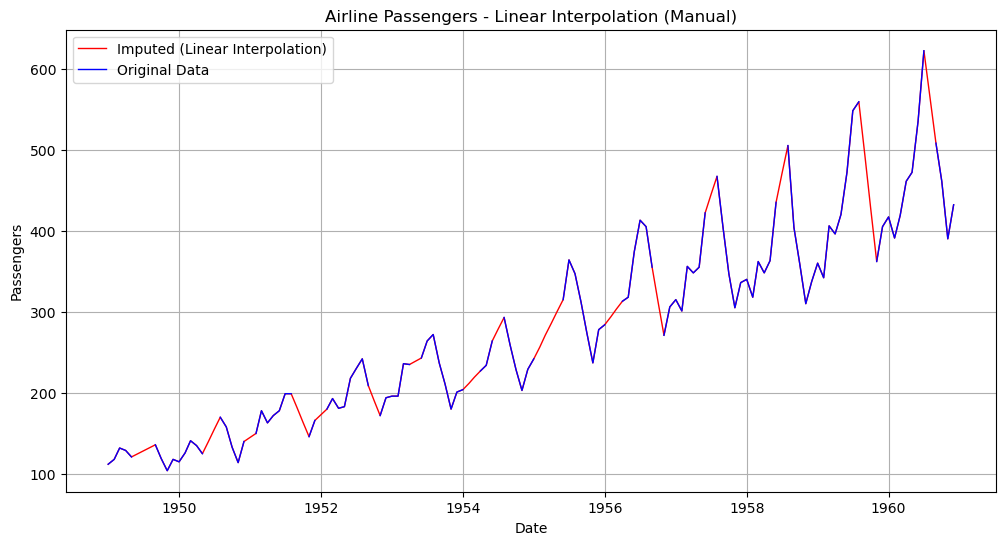

In [228]:
def impute_linear(df, column_name):
    data = df[column_name].tolist()
    n = len(data)
    i = 0
    
    while i < n:
        if pd.isna(data[i]):
            start_idx = i - 1
            # Find end of the gap
            j = i
            while j < n and pd.isna(data[j]):
                j += 1
            end_idx = j
            
            # Interpolate if we have data on both sides
            if start_idx >= 0 and end_idx < n:
                y1 = data[start_idx]
                y2 = data[end_idx]
                steps = end_idx - start_idx
                value_diff = y2 - y1
                
                for k in range(i, end_idx):
                    fraction = (k - start_idx) / steps
                    data[k] = y1 + (fraction * value_diff)
            i = end_idx
        else:
            i += 1

    df[column_name] = data
    return df

# 2. Apply Function
airlines_interpolated = airlines_missing.copy()
airlines_interpolated = impute_linear(airlines_interpolated, 'Passengers')

# 3. Plotting
plt.figure(figsize=(12, 6))
# Plot Imputed Data (Red)
plt.plot(airlines_interpolated['Month'], airlines_interpolated['Passengers'], 
         color='red', linewidth=1, label='Imputed (Linear Interpolation)')
# Plot Original Data (Blue)
plt.plot(airlines_missing['Month'], airlines_missing['Passengers'], 
         color='blue', linewidth=1, label='Original Data')

plt.title('Airline Passengers - Linear Interpolation (Manual)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

### (c) 
There is another common method to impute missing values for time series data: Last
Observation Carried Forward (LOCF), which is using the last observed value as the
imputed value for the future missing time step. Define a function impute_locf to
impute missing values with this method. In the answer, provide one time series plot
with the original data in one color, and the imputed data in another color, similar to
the plot in (a).

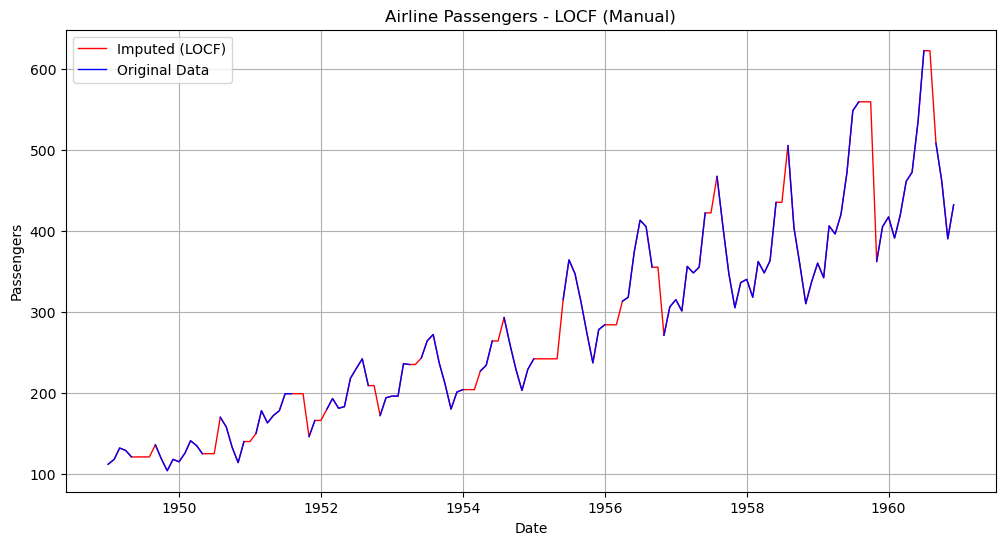

In [229]:
def impute_locf(df, column_name):
    data = df[column_name].tolist()
    last_valid_value = None
    
    for i in range(len(data)):
        if pd.notna(data[i]):
            last_valid_value = data[i]
        elif last_valid_value is not None:
            data[i] = last_valid_value
            
    df[column_name] = data
    return df

# 2. Apply Function
airlines_locf = airlines_missing.copy()
airlines_locf = impute_locf(airlines_locf, 'Passengers')

# 3. Plotting
plt.figure(figsize=(12, 6))
# Plot Imputed Data (Red)
plt.plot(airlines_locf['Month'], airlines_locf['Passengers'], 
         color='red', linewidth=1, label='Imputed (LOCF)')
# Plot Original Data (Blue)
plt.plot(airlines_missing['Month'], airlines_missing['Passengers'], 
         color='blue', linewidth=1, label='Original Data')

plt.title('Airline Passengers - LOCF (Manual)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()